In [2]:
import numpy as np
!ls
data=np.load('mnist_test_seq.npy')

mnist_test_seq.npy read_mmnist.ipynb


In [8]:
print(data.shape)
print(data.dtype)
import xarray as xr
data_xr = xr.DataArray(data)
dset=xr.Dataset({'data':data_xr})
comp = dict(zlib=True, complevel=5)
encoding = {var: comp for var in dset.variables}
dset.to_netcdf('mnist_test_seq.nc', encoding=encoding)

(20, 10000, 64, 64)
uint8


In [19]:
fname='https://thredds.rda.ucar.edu/thredds/dodsC/files/g/d559000/wy2018/201806/wrf3d_d01_2018-06-25_05:00:00.nc'
import netCDF4 as nc
ds = nc.Dataset(fname)

In [20]:
xlong=ds['XLONG'][:]
xlat=ds['XLAT'][:]
REFL=ds['REFL_10CM'][:]

(1015, 1367)
(1015, 1367)
(1, 50, 1015, 1367)


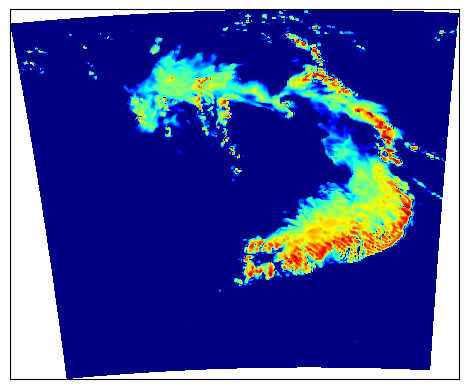

In [27]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
ax=plt.axes(projection=ccrs.PlateCarree())
print(xlong.shape)
print(xlat.shape)
print(REFL.shape)
nx1,nx2=450,800
ny1,ny2=300,700
plt.pcolormesh(xlong[ny1:ny2,nx1:nx2],xlat[ny1:ny2,nx1:nx2],REFL[0,0,ny1:ny2,nx1:nx2],transform=ccrs.PlateCarree(),cmap='jet',vmin=0)
ax.coastlines()


In [34]:
print(ds.variables.keys())
print(ds['Z'])
print(ds['TK'])
print("reading p_hyd")
p_hyd=ds['P_HYD'][0,:,ny1:ny2,nx1:nx2]
print("reading z")
z=ds['Z'][0,:,ny1:ny2,nx1:nx2]
print("reading tk")
tk=ds['TK'][0,:,ny1:ny2,nx1:nx2]
print("reading qvapor")
qv=ds['QVAPOR'][0,:,ny1:ny2,nx1:nx2]
print("reading qc")
qc=ds['QCLOUD'][0,:,ny1:ny2,nx1:nx2]
print("reading qr")
qr=ds['QRAIN'][0,:,ny1:ny2,nx1:nx2]
print("reading qs")
qs=ds['QSNOW'][0,:,ny1:ny2,nx1:nx2]
print("reading qg")
qg=ds['QGRAUP'][0,:,ny1:ny2,nx1:nx2]
print("reading qice")
qice=ds['QICE'][0,:,ny1:ny2,nx1:nx2]
print("reading qh")

dict_keys(['Time', 'XLAT', 'XLONG', 'XLAT_U', 'XLONG_U', 'XLAT_V', 'XLONG_V', 'CLDFRA', 'O3RAD', 'P', 'P_HYD', 'QCLOUD', 'QGRAUP', 'QICE', 'QNICE', 'QNRAIN', 'QRAIN', 'QSNOW', 'QVAPOR', 'REFL_10CM', 'TK', 'Times', 'U', 'V', 'W', 'XTIME', 'Z', 'ilev', 'lev'])
<class 'netCDF4.Variable'>
float32 Z(Time, bottom_top_stag, south_north, west_east)
    coordinates: XLONG XLAT XTIME
    stagger: Z
    units: m2 s-2
    description: Geopotential height (PH + PHB)/9.81
    _ChunkSizes: [   1   51 1015 1367]
unlimited dimensions: Time
current shape = (1, 51, 1015, 1367)
filling off
<class 'netCDF4.Variable'>
float32 TK(Time, bottom_top, south_north, west_east)
    description: Air Temperature
    coordinates: XLONG XLAT XTIME
    units: K
    _ChunkSizes: [   1   50 1015 1367]
unlimited dimensions: Time
current shape = (1, 50, 1015, 1367)
filling off
reading p_hyd
reading z
reading tk
reading qvapor
reading qc
reading qr
reading qs
reading qg
reading qice
reading qh


In [37]:
dbz=ds['REFL_10CM'][0,:,ny1:ny2,nx1:nx2]
qnrain=ds['QNRAIN'][0,:,ny1:ny2,nx1:nx2]
qnice=ds['QNICE'][0,:,ny1:ny2,nx1:nx2]

In [38]:
qr_xr=xr.DataArray(qr.astype(np.float32),dims=['z','y','x'])
qs_xr=xr.DataArray(qs.astype(np.float32),dims=['z','y','x'])
qg_xr=xr.DataArray(qg.astype(np.float32),dims=['z','y','x'])
qice_xr=xr.DataArray(qice.astype(np.float32),dims=['z','y','x'])
qc_xr=xr.DataArray(qc.astype(np.float32),dims=['z','y','x'])
p_hyd_xr=xr.DataArray(p_hyd.astype(np.float32),dims=['z','y','x'])
z_xr=xr.DataArray(z.astype(np.float32),dims=['z1','y','x'])
tk_xr=xr.DataArray(tk.astype(np.float32),dims=['z','y','x'])
qv_xr=xr.DataArray(qv.astype(np.float32),dims=['z','y','x'])
qnice_xr=xr.DataArray(qnice.astype(np.float32),dims=['z','y','x'])
qnrain_xr=xr.DataArray(qnrain.astype(np.float32),dims=['z','y','x'])
dbz_xr=xr.DataArray(dbz.astype(np.float32),dims=['z','y','x'])
xlong_xr=xr.DataArray(xlong[ny1:ny2,nx1:nx2].astype(np.float32),dims=['y','x'])
xlat_xr=xr.DataArray(xlat[ny1:ny2,nx1:nx2].astype(np.float32),dims=['y','x'])
dset=xr.Dataset({'qr':qr_xr,'qs':qs_xr,'qg':qg_xr,'qice':qice_xr,'qc':qc_xr,'p_hyd':p_hyd_xr,'z':z_xr,'tk':tk_xr,'qv':qv_xr,'xlong':xlong_xr,'xlat':xlat_xr,'qnice':qnice_xr,'qnrain':qnrain_xr,'dbz':dbz_xr})
comp = dict(zlib=True, complevel=5)
encoding = {var: comp for var in dset.variables}
dset.to_netcdf('wrf3d_d01_2018-06-25_05:00:00_subset.nc', encoding=encoding)

(50, 400, 350)
250 51


/var/folders/x_/d2_jzyq50052xh1_tk02bnmc0000gq/T/ipykernel_81653/1399604957.py:47: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  c=plt.pcolormesh(xrange,zm[:,:]/1e3,dbz_sectm,cmap='jet',vmin=0)


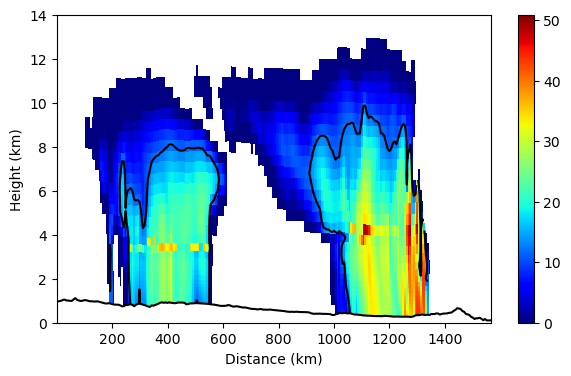

In [1]:
#dset=xr.Dataset({'qr':qr_xr,'qs':qs_xr,'qg':qg_xr,'qice':qice_xr,'qc':qc_xr,'p_hyd':p_hyd_xr,'z':z_xr,'tk':tk_xr,'qv':qv_xr,'xlong':xlong_xr,'xlat':xlat_xr,'qnice':qnice_xr,'qnrain':qnrain_xr,'dbz':dbz_xr})
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
with nc.Dataset('wrf3d_d01_2018-06-25_05:00:00_subset.nc') as ds:
    z=ds['z'][:]
    dbz=ds['dbz'][:]
    qc=ds['qc'][:]
    qr=ds['qr'][:]
    qs=ds['qs'][:]
    qg=ds['qg'][:]
    qice=ds['qice'][:]
    xlong=ds['xlong'][:]
    xlat=ds['xlat'][:]
    p_hyd=ds['p_hyd'][:]
    tk=ds['tk'][:]
    qv=ds['qv'][:]

print(dbz.shape)
irange=np.arange(100,350)
jrange=np.linspace(400,100,250)
plt.figure(figsize=(7,4))
#print(jrange)
z1L=[]
dbz_sectL=[]
i_last=100
j_last=399
dL=[]
for i1,j1 in zip(irange,jrange):
    i1_=int(i1)
    j1_=int(j1)-1
    d=np.sqrt((i1-i_last)**2+(j1-j_last)**2)
    if len(dL)==0:
        dL.append(d*4)
    else:
        dL.append(d*4+dL[-1])
    i_last=i1
    j_last=j1
    z1L.append(z[:,j1_,i1_])
    dbz_sectL.append(dbz[:,j1_,i1_])
print(len(z1L),len(z1L[0]))
dbz_sect=np.array(dbz_sectL)
dbz_sectm=np.ma.masked_where(dbz_sect<-10,dbz_sect)
z1L=np.array(z1L)
xrange=np.array([dL for k in range(50)]).T
zm=(z1L[:,:-1]+z1L[:,1:])/2
c=plt.pcolormesh(xrange,zm[:,:]/1e3,dbz_sectm,cmap='jet',vmin=0)  
plt.contour(xrange,zm[:,:]/1e3,dbz_sectm,levels=[12],colors='k')
plt.xlabel('Distance (km)')
plt.ylabel('Height (km)')
plt.plot(xrange[:,0],z1L[:,0]/1e3,'k')
plt.ylim(0,14)
plt.colorbar(c)

In [2]:
print(dL)

freqs=np.array([89, 183.31 + 0.2, 183.31 + 1.1, 183.31 + 2.8, 183.31 + 4.2, 183.31 + 6.8, 183.31 + 11, 325.15 + 1.1, 325.15 + 3.5,325.15 + 9.5])
#print(freqs.mean())

[4.0, 10.263020984147555, 16.52604196829529, 22.789062952442844, 29.0520839365904, 35.31510492073813, 41.57812590488569, 47.84114688903342, 54.10416787318098, 60.367188857328536, 66.63020984147627, 72.89323082562383, 79.15625180977139, 85.41927279391912, 91.68229377806668, 97.94531476221424, 104.20833574636197, 110.47135673050953, 116.73437771465726, 122.99739869880482, 129.26041968295237, 135.52344066710012, 141.78646165124766, 148.0494826353952, 154.31250361954295, 160.5755246036905, 166.83854558783804, 173.10156657198579, 179.36458755613333, 185.62760854028087, 191.89062952442862, 198.15365050857616, 204.4166714927239, 210.67969247687145, 216.942713461019, 223.20573444516674, 229.46875542931429, 235.73177641346203, 241.99479739760957, 248.25781838175712, 254.52083936590466, 260.7838603500524, 267.04688133419995, 273.30990231834767, 279.5729233024952, 285.83594428664276, 292.0989652707905, 298.361986254938, 304.62500723908573, 310.8880282232333, 317.1510492073808, 323.41407019152837,

In [3]:
#d_pickle={'dict_freqx':d_index,'ind_tables':scatt_ind}
import pickle
d_pickle=pickle.load(open('d_pickle.pklz','rb'))
print(d_pickle)
nfreqs=3
hydromet_ssp=[]
ny,nx=qr.shape[1:]
import lkTables
lkT=lkTables.scattTables()
print(dir(lkT))
rho=p_hyd/(287.05*tk)
#print(rho[0,0,0],rho.max(),rho.min())
rwc=qr*1e3*rho
swc=qs*1e3*rho
gwc=qg*1e3*rho
iwc=qice*1e3*rho
iwc_tot=(swc+gwc+iwc)
ind_tables=d_pickle['ind_tables']
dict_freqx=d_pickle['dict_freqx']
ifreqs=np.array([dict_freqx[ifreq] for ifreq in freqs])
print(ifreqs)

{'dict_freqx': {89.0: 2, 183.51: 3, 184.41: 3, 186.11: 3, 187.51: 3, 190.11: 3, 194.31: 3, 326.25: 4, 328.65: 4, 334.65: 4}, 'ind_tables': [2, 3, 4]}
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'asymBB', 'asymG', 'asymR', 'asymS', 'attKaBB', 'attKaG', 'attKaR', 'attKaS', 'attKuBB', 'attKuG', 'attKuR', 'attKuS', 'dmBB', 'dmg', 'dmr', 'dms', 'fh', 'fhBB', 'fhGMI', 'graupRate', 'gwc', 'kextBB', 'kextG', 'kextR', 'kextS', 'precRateBB', 'rainRate', 'rwc', 'salbBB', 'salbG', 'salbR', 'salbS', 'snowRate', 'swc', 'zKaBB', 'zKaG', 'zKaR', 'zKaS', 'zKuBB', 'zKuG', 'zKuR', 'zKuS']
[2 3 3 3 3 3 3 4 4 4]


In [4]:
a=np.nonzero(iwc_tot>0.001)
b=np.nonzero(rwc>0.001)
print(len(a[0]),len(b[0]))
nz=50
nfreqs=10
rain_kext=np.zeros((nz,ny,nx,nfreqs),dtype=np.float32)
rain_ksca=np.zeros((nz,ny,nx,nfreqs),dtype=np.float32)
rain_g=np.zeros((nz,ny,nx,nfreqs),dtype=np.float32)

ice_kext=np.zeros((nz,ny,nx,nfreqs),dtype=np.float32)
ice_ksca=np.zeros((nz,ny,nx,nfreqs),dtype=np.float32)
ice_g=np.zeros((nz,ny,nx,nfreqs),dtype=np.float32)

with nc.Dataset('rain_mie_integrated_prop.nc') as f:
    rwc_table=f['rwc'][:].data
    dm_rain_table=f['dm'][:].data
    kext_rain_table=f['kext'][:]
    ksca_rain_table=f['ksca'][:]
    g_rain_table=f['g'][:]

with nc.Dataset('ice_SSRG_integrated_prop.nc') as f:
    iwc_table=f['rwc'][:].data
    dm_ice_table=f['dm'][:].data
    kext_ice_table=f['kext'][:]
    ksca_ice_table=f['ksca'][:]
    g_ice_table=f['g'][:]
import bisectm

for k1,j1,i1 in zip(b[0],b[1],b[2]):
    ibin=bisectm.bisectm(rwc_table,rwc[k1,j1,i1])
    rain_kext[k1,j1,i1,:]=kext_rain_table[ifreqs,ibin]
    rain_ksca[k1,j1,i1,:]=ksca_rain_table[ifreqs,ibin]
    rain_g[k1,j1,i1,:]=g_rain_table[ifreqs,ibin]

for k1,j1,i1 in zip(a[0],a[1],a[2]):
    ibin=bisectm.bisectm(iwc_table,iwc_tot[k1,j1,i1])
    ice_kext[k1,j1,i1,:]=kext_ice_table[ifreqs,ibin]
    ice_ksca[k1,j1,i1,:]=ksca_ice_table[ifreqs,ibin]
    ice_g[k1,j1,i1,:]=g_ice_table[ifreqs,ibin]
    #if rwc[k1,j1,i1]>0.1:
    #    print(rwc[k1,j1,i1],dm_rain_table[ibin])
#for i in range(nx):
#    for j in range(ny):


895207 431634


In [7]:
#z.shape
#z[:,:2,:2].reshape(nz+1,4)[:,0]
#p_hyd[:,0,0]
#qv[:,0,0]
ifreq=ind_tables
incAngle=53.0
print(ifreq)
print(freqs)
import sdsu_tables
print(dir(sdsu_tables))
nz,ny,nx=qv.shape
qv_=qv[:,:,:].reshape(-1,nx*ny)
z_=z[:,:,:].reshape(-1,nx*ny)/1e3
temperature_=tk[:,:,:].reshape(-1,nx*ny)
press_=p_hyd[:,:,:].reshape(-1,nx*ny)
rain_kext_=rain_kext[:,:,:,:].reshape(-1,nx*ny,nfreqs)
rain_ksca_=rain_ksca[:,:,:,:].reshape(-1,nx*ny,nfreqs)
rain_g_=rain_g[:,:,:,:].reshape(-1,nx*ny,nfreqs)
snow_kext_=ice_kext[:,:,:,:].reshape(-1,nx*ny,nfreqs)
snow_ksca_=ice_ksca[:,:,:,:].reshape(-1,nx*ny,nfreqs)
snow_g_=ice_g[:,:,:,:].reshape(-1,nx*ny,nfreqs)
ifreqs_=np.array(ifreqs)+1
print(nz,ny,nx)
print(z.shape)
print(qv_.shape)
print(z_.shape)
print(temperature_.shape)
print("------")
tb_all_freq = sdsu_tables.calculate_tb_hyd(incAngle,freqs,qv_,z_,temperature_,press_,\
    rain_kext_,rain_ksca_,rain_g_,snow_kext_,snow_g_,snow_g_)#,[nxny,nz,nifreq,nfreqs])
print("______")
print(tb_all_freq.shape)
print(tb_all_freq[0,:])

[2, 3, 4]
[ 89.   183.51 184.41 186.11 187.51 190.11 194.31 326.25 328.65 334.65]
['__doc__', '__f2py_numpy_version__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__version__', '_sdsu_tables_error', 'abh2o', 'abliq', 'absn2', 'absorb_py', 'calculate_tb_hyd', 'calculate_tb_prof', 'calculate_tb_prof_emiss', 'diecon', 'diecon2', 'emiss', 'emiss2', 'emit', 'emit2', 'gasabsr98', 'microp_set', 'mie_cldw', 'o2abs', 'o2com1', 'q2wkg', 'qv2rh', 'radtran', 'radtran_check', 'vapor']
50 400 350
(51, 400, 350)
(50, 140000)
(51, 140000)
(50, 140000)
------
          50           1      140000          50
______
(140000, 10)
[276.54044 244.83331 257.34167 270.85614 276.41858 282.7156  286.8578
 256.97064 271.70682 279.60306]


In [8]:
print(tb_all_freq[0,:]) 
print(z_[:,0])

[-1.4758658e+02            nan            nan            nan
           -inf -5.1827212e+28 -9.8516087e+16            nan
            nan           -inf]
[1.5530973672866821 1.6049091815948486 1.6670273542404175
 1.7396091222763062 1.8224050998687744 1.9155302047729492
 2.0188660621643066 2.1426784992218018 2.2869553565979004
 2.451415777206421 2.635991096496582 2.840641498565674 3.075371026992798
 3.339900255203247 3.6338913440704346 3.9569671154022217 4.319393157958984
 4.722375392913818 5.16623067855835 5.648931503295898 6.130410194396973
 6.610718727111816 7.089322566986084 7.565998077392578 8.040753364562988
 8.514126777648926 8.986684799194336 9.457945823669434 9.928065299987793
 10.397271156311035 10.865874290466309 11.334136962890625
 11.801487922668457 12.26787281036377 12.73305892944336 13.197532653808594
 13.66159439086914 14.12583065032959 14.592981338500977 15.065689086914062
 15.543991088867188 16.027788162231445 16.519977569580078
 17.022663116455078 17.536230087280273 1